In [34]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, roc_auc_score,log_loss,f1_score

In [35]:
data = load_breast_cancer()

X = data.data
y = data.target
# print(data.data.shape)
print("Feature matrix shape:", X.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)


Feature matrix shape: (569, 30)


In [36]:
scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(X_train)
Xtest_scaled = scaler.transform(X_test)

In [37]:
#  PCA
pca = PCA(n_components=2)   # Reduce to 2 principal components
Xtrain_pca = pca.fit_transform(Xtrain_scaled)
Xtest_pca = pca.transform(Xtest_scaled)


In [ ]:
ann = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42)
ann.fit(Xtrain_pca, y_train)
# ann.fit(X_train, y_train)
y_pred = ann.predict(Xtest_pca)
# y_pred = ann.predict(X_test)
y_prob = ann.predict_proba(Xtest_pca)[:, 1]

In [ ]:
###using KNN
# model=KNeighborsClassifier(n_neighbors=5)
# model.fit(Xtrain_pca,y_train)
# y_pred=model.predict(Xtest_pca)
# y_prob=model.predict_proba(Xtest_pca)[:,1]

In [40]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nPrecision: ",precision_score(y_test, y_pred))
print("\nAUC-ROC: ", roc_auc_score(y_test, y_prob)) 
print("\nRecall: ", recall_score(y_test, y_pred))
print("\nLog Loss: ", log_loss(y_test, y_prob))
print("\nF1 Score: ",f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.958041958041958

Precision:  0.9882352941176471

AUC-ROC:  0.995110278818144

Recall:  0.9438202247191011

Log Loss:  0.08361737382369706

F1 Score:  0.9655172413793104

Confusion Matrix:
 [[53  1]
 [ 5 84]]


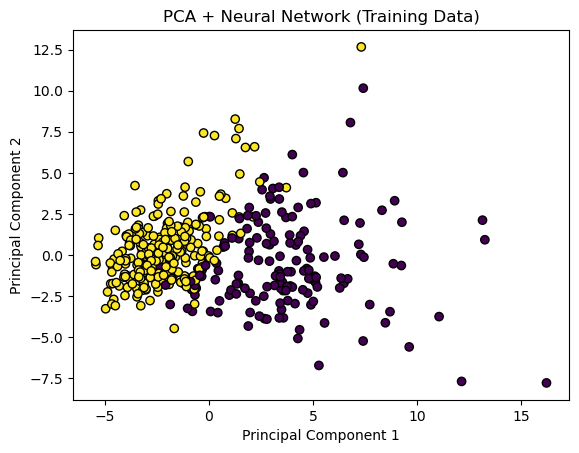

In [41]:
plt.scatter(
    Xtrain_pca[:, 0],
    Xtrain_pca[:, 1],
    c=y_train,
    cmap='viridis',
    edgecolor='k'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA + Neural Network (Training Data)")
plt.show()